# Shoreline band-depth analysis (distance to baseline)

This notebook computes the band-depth and 50% envelope for shorelines in each folder, but instead of using PCA axes, it measures the perpendicular distance from each curve to a specified baseline shoreline (given as a path to a LabelMe JSON file).

- For each folder, all curves are projected to the baseline using nearest-point distance.
- The boxplot and band are computed using these distances.
- Outliers are flagged by depth, and the plot overlays the baseline, the 50% band, the median, and outliers.

## Parameters
- `baseline_json_path`: Path to the baseline LabelMe JSON file.
- `base_root`: Root folder containing subfolders of LabelMe JSONs.
- `M`: Number of samples along the baseline (default 200).

[jennette_north-2025-10-12-152417Z] Depths in 0.008s, D shape (1249, 200)
Saved plot to ./jennettes_pier\jennette_north-2025-10-12-152417Z\curve_boxplot_baseline.png


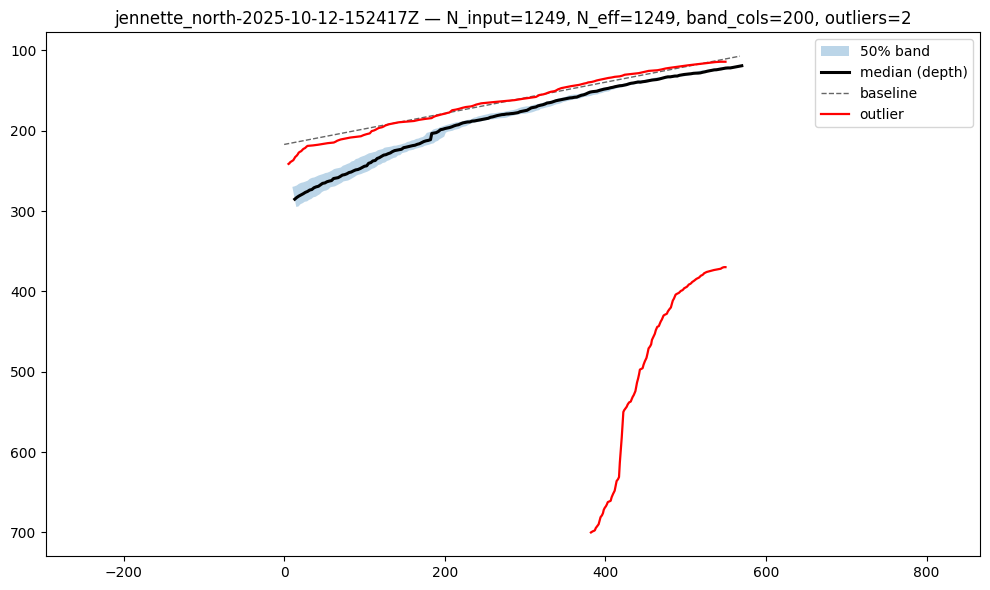

Saved depths to ./jennettes_pier\jennette_north-2025-10-12-152417Z\depths_baseline.json
[jennette_north-2025-10-12-155417Z] Depths in 0.006s, D shape (928, 200)
Saved plot to ./jennettes_pier\jennette_north-2025-10-12-155417Z\curve_boxplot_baseline.png
[jennette_north-2025-10-12-155417Z] Depths in 0.006s, D shape (928, 200)
Saved plot to ./jennettes_pier\jennette_north-2025-10-12-155417Z\curve_boxplot_baseline.png


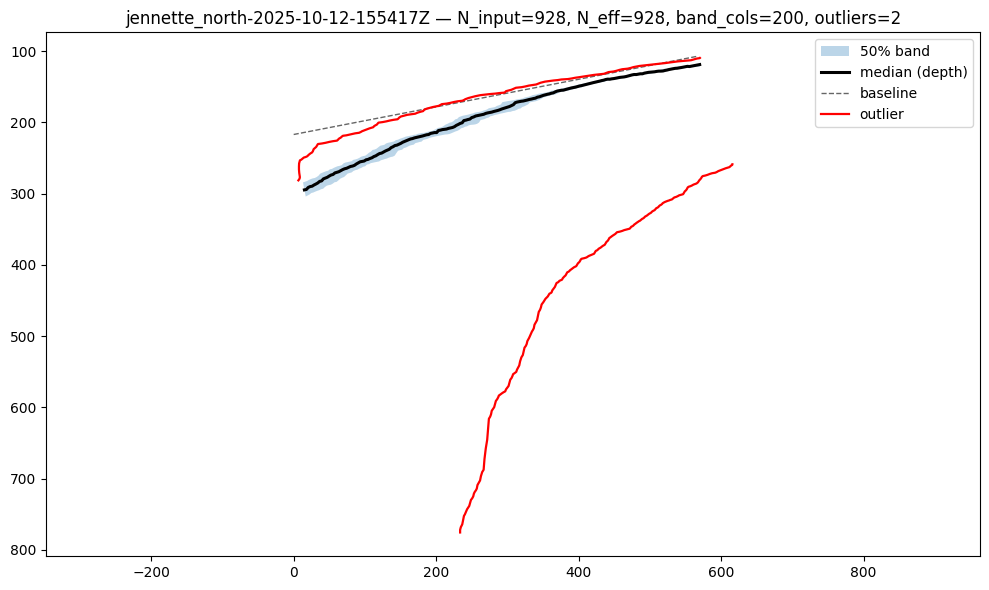

Saved depths to ./jennettes_pier\jennette_north-2025-10-12-155417Z\depths_baseline.json
[jennette_north-2025-10-12-174405Z] Depths in 0.007s, D shape (1094, 200)
Saved plot to ./jennettes_pier\jennette_north-2025-10-12-174405Z\curve_boxplot_baseline.png
[jennette_north-2025-10-12-174405Z] Depths in 0.007s, D shape (1094, 200)
Saved plot to ./jennettes_pier\jennette_north-2025-10-12-174405Z\curve_boxplot_baseline.png


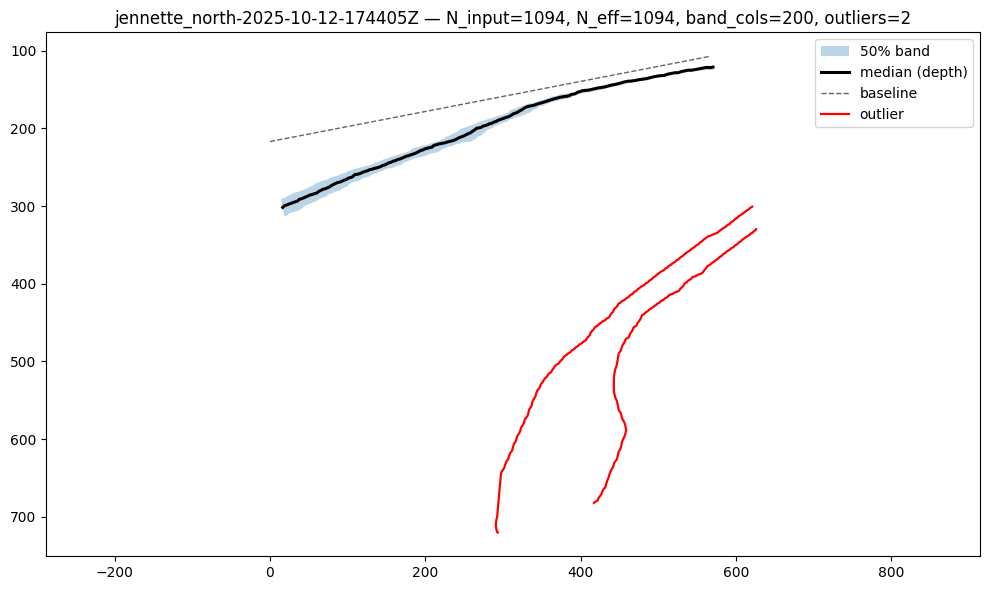

Saved depths to ./jennettes_pier\jennette_north-2025-10-12-174405Z\depths_baseline.json
Done.


: 

In [ ]:
# ======================= #
# Baseline-referenced Curve Boxplot for Shorelines
# ======================= #

# --- Parameters ---
baseline_json_path = './jennettes_pier/jennette_north-2025-10-12-152417Z_000008.json'  # baseline JSON (LabelMe)
base_root = './jennettes_pier/'      # root containing one or more subfolders of LabelMe JSONs
process_subfolders = []              # [] -> auto-detect subfolders; or list like ["jennette_north-2025-10-12-152417Z"]

M = 200                 # samples along the baseline (common s-grid)
smoothing_window = 5    # 0/None to disable; else odd >=3
min_points = 8          # skip super-short polylines
coverage_row_frac = 0.50   # require >= this fraction of valid samples to keep a curve (only used if we mask far points)
band_valid_frac = 0.60     # draw blue band where >= this fraction of central curves are valid at that s
max_outliers_to_plot = 2   # exactly K outliers per figure
max_assign_dist_px = None  # e.g., 60: mask distances > 60 px as NaN; None -> keep all

save_plot = True
save_json = True
verbose = True

# --- Imports ---
import os, glob, json, time, math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import patches

try:
    from scipy.spatial import cKDTree as KDTree
except Exception:
    KDTree = None   # will use slower fallback

# --- IO helpers ---
def load_labelme_shoreline(json_path, label='shoreline'):
    with open(json_path, 'r') as f:
        j = json.load(f)
    for sh in j.get("shapes", []):
        if str(sh.get("label","")).lower() == label:
            pts = np.array(sh.get("points", []), dtype=float)
            return pts if pts.size else None
    return None

def dedupe_and_short_remove(pts, eps=0.5):
    if pts is None or len(pts) == 0: return None
    keep=[0]
    for i in range(1, len(pts)):
        if np.linalg.norm(pts[i] - pts[keep[-1]]) > eps:
            keep.append(i)
    out = pts[keep]
    return out if len(out) >= 2 else None

def smooth_curve(pts, window=None):
    if window is None or window < 3 or len(pts) < 3: return pts
    w = int(window); w += (w % 2 == 0)
    pad = w//2
    x, y = pts[:,0], pts[:,1]
    xp = np.pad(x, (pad,pad), mode='reflect')
    yp = np.pad(y, (pad,pad), mode='reflect')
    k = np.ones(w)/w
    xs = np.convolve(xp, k, mode='valid')
    ys = np.convolve(yp, k, mode='valid')
    return np.vstack([xs, ys]).T

def arc_length_resample(pts, M):
    seg = pts[1:] - pts[:-1]
    s = np.concatenate([[0.0], np.cumsum(np.linalg.norm(seg, axis=1))])
    if s[-1] <= 0: return None, None
    t = s / s[-1]
    grid = np.linspace(0.0, 1.0, M)
    X = np.interp(grid, t, pts[:,0])
    Y = np.interp(grid, t, pts[:,1])
    return np.column_stack([X, Y]), s[-1]

def finite_diff_normals(poly):
    # poly: (M,2) in order
    T = np.gradient(poly, axis=0)  # tangents (not unit)
    # rotate tangents by +90° to get normals
    N = np.stack([ T[:,1], -T[:,0] ], axis=1)
    n_norm = np.linalg.norm(N, axis=1) + 1e-12
    N = N / n_norm[:,None]
    return N  # (M,2), approximately unit

def reorder_by_projection_axis(pts, axis_vec):
    # sort points by projection onto axis_vec
    s = pts @ axis_vec
    return pts[np.argsort(s)]

def median_filter_1d(a, k=3):
    if k is None or k < 3: return a
    pad = k//2
    ap = np.pad(a, (pad,pad), mode="reflect")
    out = np.empty_like(a)
    for i in range(len(a)):
        out[i] = np.median(ap[i:i+k])
    return out

# --- Depth (rank-based, exact J=2) ---
def band_depth_functions_masked(D):
    """Exact J=2 band-depth for functions with NaNs; O(M * sort(N))."""
    N, M = D.shape
    depths = np.zeros(N, float)
    denom = 0.0
    for k in range(M):
        valid = ~np.isnan(D[:,k])
        idx = np.where(valid)[0]
        n = idx.size
        if n < 2: 
            continue
        vals = D[idx, k]
        order_local = np.argsort(vals, kind='mergesort')    # stable
        ordered_rows = idx[order_local]
        # ranks 1..n for ordered rows
        ranks = np.arange(1, n+1, dtype=np.int64)
        contrib = (ranks-1)*(n-ranks)                       # length n
        depths[ordered_rows] += contrib
        denom += math.comb(n, 2)
    return depths / max(denom, 1.0)

# --- Plot helpers ---
def draw_ribbon(ax, x1, y1, x2, y2, mask, **kw):
    idx = np.where(mask)[0]
    if idx.size == 0: return
    splits = np.where(np.diff(idx) > 1)[0] + 1
    runs = np.split(idx, splits)
    for run in runs:
        poly = np.vstack([
            np.column_stack([x1[run], y1[run]]),
            np.column_stack([x2[run[::-1]], y2[run[::-1]]])
        ])
        ax.add_patch(patches.Polygon(poly, closed=True, **kw))

def plot_by_axis_with_breaks(ax, pts, axis_vec, color='0.85', lw=0.6):
    s = pts @ axis_vec
    order = np.argsort(s)
    P = pts[order]
    s_sorted = s[order]
    ds = np.diff(s_sorted)
    thr = 5.0 * (np.median(np.abs(ds)) + 1e-9)
    breaks = np.where(np.abs(ds) > thr)[0] + 1
    runs = np.split(np.arange(len(P)), breaks)
    for r in runs:
        if len(r) >= 2:
            seg = P[r]
            ax.plot(seg[:,0], seg[:,1], color=color, linewidth=lw, zorder=1.5)

# --- Baseline -> distances ---
def distances_to_baseline(curve_pts, B, N, tree=None):
    """
    For each baseline sample k, find nearest point on the curve and take signed distance
    along baseline normal: d_k = (curve_near - B_k) · N_k.
    If max_assign_dist_px is set, values farther than that are NaN.
    """
    if tree is None:
        # brute force (slower)
        dists = np.empty(B.shape[0], float)
        for k, bk in enumerate(B):
            diffs = curve_pts - bk[None,:]
            j = np.argmin(np.einsum('ij,ij->i', diffs, diffs))
            vec = curve_pts[j] - bk
            d = vec @ N[k]
            dists[k] = d
    else:
        # fast k-NN (k=1)
        d, j = tree.query(B, k=1)
        vecs = curve_pts[j] - B
        dists = np.einsum('ij,ij->i', vecs, N)
        if isinstance(d, np.ndarray):
            radial = d
        else:
            radial = np.array([d]*B.shape[0])
    # Optional masking by radial distance to avoid mapping far-away junk
    if max_assign_dist_px is not None:
        # Compute true Euclidean nearest distance if KDTree available; else reuse |dists| as proxy
        if KDTree is not None and tree is not None:
            radial = np.linalg.norm(curve_pts[j] - B, axis=1)
        else:
            radial = np.abs(dists)
        mask = radial > max_assign_dist_px
        dists = dists.astype(float)
        dists[mask] = np.nan
    return dists

# --- Build baseline once ---
baseline_pts = load_labelme_shoreline(baseline_json_path)  # <-- change to accept label argument below
if baseline_pts is None:
    # Try loading with label 'baseline' instead of 'shoreline'
    baseline_pts = load_labelme_shoreline(baseline_json_path, label='baseline')
assert baseline_pts is not None, "Baseline not found: check label in JSON ('baseline') and path."

baseline_pts = dedupe_and_short_remove(baseline_pts, eps=0.5)
baseline_pts = smooth_curve(baseline_pts, smoothing_window)

# use baseline itself to define axis; resample to M, and get normals
B_resampled, Lb = arc_length_resample(baseline_pts, M)
assert B_resampled is not None, "Baseline resampling failed."
# tangents/normals along baseline
N_baseline = finite_diff_normals(B_resampled)
# along-shore plotting axis: baseline principal direction
axis_vec = (B_resampled[-1] - B_resampled[0])
axis_vec = axis_vec / (np.linalg.norm(axis_vec) + 1e-12)

# --- Runner over folders ---
subfolders = [base_root] if not any(os.path.isdir(p) for p in glob.glob(os.path.join(base_root, '*'))) else \
             sorted([d for d in glob.glob(os.path.join(base_root, '*')) if os.path.isdir(d)])
if process_subfolders:
    subfolders = [os.path.join(base_root, s) for s in process_subfolders]

for folder_path in subfolders:
    # Load curves in folder
    jsons = sorted(glob.glob(os.path.join(folder_path, "*.json")))
    curves_raw, files_raw = [], []
    for jf in jsons:
        pts = load_labelme_shoreline(jf)
        if pts is None: continue
        pts = dedupe_and_short_remove(pts, eps=0.5)
        if pts is None or len(pts) < min_points: continue
        pts = smooth_curve(pts, smoothing_window)
        curves_raw.append(pts)
        files_raw.append(os.path.basename(jf))

    if not curves_raw:
        print(f"No shorelines in {folder_path}")
        continue

    # Build KDTree per curve if available (speed)
    trees = []
    if KDTree is not None:
        for pts in curves_raw:
            trees.append(KDTree(pts))
    else:
        trees = [None]*len(curves_raw)

    # Build D: distances to baseline along normals
    D = np.full((len(curves_raw), M), np.nan, float)
    for i, pts in enumerate(curves_raw):
        D[i,:] = distances_to_baseline(pts, B_resampled, N_baseline, tree=trees[i])

    # Coverage filter if we masked far points
    if max_assign_dist_px is not None:
        row_frac = np.mean(~np.isnan(D), axis=1)
        keep_rows = row_frac >= coverage_row_frac
        D = D[keep_rows,:]
        files_kept = [files_raw[i] for i in np.where(keep_rows)[0]]
        kept_indices = np.where(keep_rows)[0].tolist()
    else:
        files_kept = files_raw
        kept_indices = list(range(len(files_raw)))

    if D.shape[0] == 0:
        print(f"No usable curves after coverage filtering in {folder_path}")
        continue

    # Depths + central set
    t0 = time.time()
    depths = band_depth_functions_masked(D)
    if verbose:
        print(f"[{os.path.basename(folder_path)}] Depths in {time.time()-t0:.3f}s, D shape {D.shape}")

    order = np.argsort(-depths)
    central_idx = order[:max(1, len(order)//2)]
    central = D[central_idx,:]

    # Band columns where enough central curves are valid
    if max_assign_dist_px is not None:
        valid_counts = np.sum(~np.isnan(central), axis=0)
        valid_mask = valid_counts >= (band_valid_frac * central.shape[0])
    else:
        # everything valid if no masking
        valid_mask = np.ones(M, dtype=bool)

    # 50% band in distance space
    Q1 = np.full(M, np.nan); Q3 = np.full(M, np.nan)
    Q1[valid_mask] = np.nanquantile(central[:, valid_mask], 0.25, axis=0)
    Q3[valid_mask] = np.nanquantile(central[:, valid_mask], 0.75, axis=0)

    # Median function (pointwise) and 2D mapping
    med_func = np.nanmedian(D, axis=0)
    P_med = B_resampled + med_func[:,None] * N_baseline
    P_Q1  = B_resampled + Q1[:,None] * N_baseline
    P_Q3  = B_resampled + Q3[:,None] * N_baseline

    # Choose exactly K outliers (lowest depths)
    K = min(max_outliers_to_plot, D.shape[0])
    worst_rows = np.argsort(depths)[:K]          # indices into D
    worst_raw_idx = [kept_indices[r] for r in worst_rows]

    # --- Plot ---
    fig, ax = plt.subplots(figsize=(10,6))

    # 50% band ribbon around baseline (builds polygon runs and adds patches)
    draw_ribbon(
        ax,
        P_Q1[:,0], P_Q1[:,1],
        P_Q3[:,0], P_Q3[:,1],
        valid_mask,
        facecolor='C0', alpha=0.30, edgecolor='none', label='50% band'
    )

    # median (pointwise median in distance-space mapped back to 2D)
    ax.plot(P_med[:,0], P_med[:,1], color='k', linewidth=2.2, label='median (depth)', zorder=4)

    # baseline (for reference)
    ax.plot(baseline_pts[:,0], baseline_pts[:,1], color='k', linestyle='--', linewidth=1.0, alpha=0.6, label='baseline', zorder=2.5)

    # outliers: plot selected worst rows (red polylines)
    first = True
    for raw_idx in worst_raw_idx:
        pts = curves_raw[raw_idx]
        ax.plot(pts[:,0], pts[:,1], color='red', lw=1.6, label='outlier' if first else None, zorder=5)
        first = False

    # title / aspect / legend
    ax.set_title(f"{os.path.basename(folder_path)} — N_input={len(files_raw)}, N_eff={D.shape[0]}, band_cols={int(valid_mask.sum())}, outliers={len(worst_rows)}")
    ax.set_aspect('equal', adjustable='datalim')
    ax.invert_yaxis()
    ax.legend(loc='best')
    plt.tight_layout()

    # save figure file (the image you saw)
    if save_plot:
        out_plot = os.path.join(folder_path, "curve_boxplot_baseline.png")
        fig.savefig(out_plot, dpi=150)
        if verbose: print("Saved plot to", out_plot)
    plt.show(); plt.close(fig)

    if save_json:
        out_json = os.path.join(folder_path, "depths_baseline.json")
        with open(out_json, "w") as f:
            json.dump({
                "folder": folder_path,
                "baseline": os.path.basename(baseline_json_path),
                "n_input_curves": len(files_raw),
                "n_effective_curves": int(D.shape[0]),
                "effective_files": [files_kept[i] for i in range(len(files_kept))] if max_assign_dist_px is not None else files_kept,
                "depths": depths.tolist(),
                "outlier_files": [files_raw[i] for i in worst_raw_idx]
            }, f, indent=2)
        if verbose: print("Saved depths to", out_json)

print("Done.")

# Outliers represent the shorelines whose distance-to-baseline functions are least central (lowest band depth).
# In other words, these are the curves whose shape, relative to the baseline, is most different from the majority.
# They are flagged by the band depth computed on the distance-to-baseline array for each curve.

# For each folder, the red outlier curves are those with the lowest depth values (most "outlying" distance profiles).